<a href="https://colab.research.google.com/github/Bienbaz/3MTT-Projects/blob/main/Logistic_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression: Airline Customer Satisfaction

## Project Overview
In this project, I use Python and `scikit-learn` to build a Logistic Regression classification model. I will preprocess categorical data, evaluate the model using a Confusion Matrix, and translate my statistical findings into actionable business recommendations for the airline.

### Step 0: Setup and Data Generation
*Note: This cell generates a synthetic airline dataset. I ensure that factors like Wi-Fi and Class have a logical mathematical relationship with the probability of satisfaction.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Generate synthetic airline data
np.random.seed(42)
n_samples = 1000

age = np.random.randint(18, 75, n_samples)
flight_distance = np.random.randint(300, 4000, n_samples)
inflight_wifi = np.random.randint(1, 6, n_samples) # Rating 1 to 5
leg_room = np.random.randint(1, 6, n_samples)      # Rating 1 to 5
cabin_class = np.random.choice(['Eco', 'Business'], n_samples, p=[0.7, 0.3])

# Create the target variable (Satisfaction) based on a hidden logistic function
# Base log-odds
log_odds = -5.0 + (0.8 * inflight_wifi) + (0.5 * leg_room) + np.where(cabin_class == 'Business', 1.5, 0)
probability = 1 / (1 + np.exp(-log_odds))
satisfaction = np.random.binomial(1, probability)

df = pd.DataFrame({
    'Age': age,
    'Flight_Distance': flight_distance,
    'Inflight_Wifi': inflight_wifi,
    'Leg_Room': leg_room,
    'Class': cabin_class,
    'Satisfaction': satisfaction # 1 = Satisfied, 0 = Neutral/Dissatisfied
})
df.to_csv('airline_satisfaction.csv', index=False)
print("✅ 'airline_satisfaction.csv' created successfully!")

✅ 'airline_satisfaction.csv' created successfully!


### Step 1: Load and Inspect the Data

In [2]:
df = pd.read_csv('airline_satisfaction.csv')
display(df.head())

# Check the balance of my target variable
print("\nTarget Variable Distribution:")
print(df['Satisfaction'].value_counts(normalize=True) * 100)

,Age,Flight_Distance,Inflight_Wifi,Leg_Room,Class,Satisfaction
0,56,2400,5,4,Eco,1
1,69,1773,2,4,Eco,0
2,46,504,2,1,Eco,1
3,32,2473,5,5,Business,1
4,60,342,4,4,Eco,0



Target Variable Distribution:
Satisfaction
0    61.3
1    38.7
Name: proportion, dtype: float64


### Step 2: Feature Engineering & Preprocessing
Machine learning models require numbers, not text. I need to convert my categorical `Class` column into dummy/indicator variables (0s and 1s).

In [3]:
# One-Hot Encode the 'Class' variable. drop_first=True avoids multicollinearity (the Dummy Variable Trap)
df_encoded = pd.get_dummies(df, columns=['Class'], drop_first=True)

display(df_encoded.head())

# Define my Features (X) and Target (y)
X = df_encoded.drop('Satisfaction', axis=1)
y = df_encoded['Satisfaction']

,Age,Flight_Distance,Inflight_Wifi,Leg_Room,Satisfaction,Class_Eco
0,56,2400,5,4,1,True
1,69,1773,2,4,0,True
2,46,504,2,1,1,True
3,32,2473,5,5,1,False
4,60,342,4,4,0,True


### Step 3: Train/Test Split
To ensure my model evaluates unseen data fairly, I split the dataset into a training set (to learn patterns) and a testing set (to evaluate performance).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (700, 5)
Testing data size: (300, 5)


### Step 4: Build and Fit the Logistic Regression Model

In [5]:
# Initialize the model
log_model = LogisticRegression(max_iter=1000)

# Fit the model on the training data
log_model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


### Step 5: Evaluate Model Performance
I predict on the test set and generate a Confusion Matrix to understand True Positives, True Negatives, False Positives, and False Negatives.

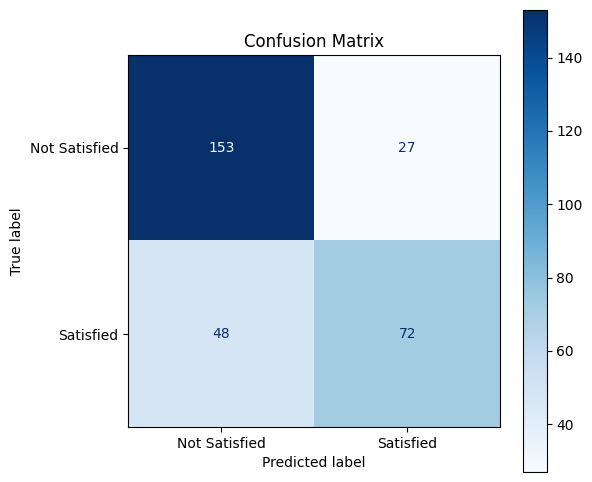


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       180
           1       0.73      0.60      0.66       120

    accuracy                           0.75       300
   macro avg       0.74      0.72      0.73       300
weighted avg       0.75      0.75      0.74       300



In [6]:
# Generate predictions
y_pred = log_model.predict(X_test)

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Satisfied', 'Satisfied'])
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Print Precision, Recall, and F1-Score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

**Metric Interpretation:**
* **Precision:** Out of all the passengers my model *predicted* were satisfied, what percentage actually were? (Crucial if I am sending expensive \"Thank You\" gifts based on predictions).
* **Recall:** Out of all the *truly* satisfied passengers, what percentage did my model successfully find? (Crucial if I want to ensure no happy customer is overlooked).

### Step 6: Interpret Coefficients and Business Impact
Unlike a black-box model, Logistic Regression provides coefficients that tell me exactly *how much* a variable influences the probability of the target outcome.

In [7]:
# Extract features and their corresponding coefficients
feature_names = X.columns
coefficients = log_model.coef_[0]

# Create a DataFrame for easy viewing
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Calculate the Odds Ratio (exp(coefficient))
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Odds_Ratio', ascending=False)

display(coef_df)

,Feature,Coefficient,Odds_Ratio
2,Inflight_Wifi,0.920840,2.511398
3,Leg_Room,0.557041,1.745499
1,Flight_Distance,-0.000089,0.999911
0,Age,-0.008241,0.991793
4,Class_Eco,-1.770365,0.170271


### Final Business Recommendation
Based on the Odds Ratio analysis, I can make the following data-backed recommendations:

1.  **Prioritize Wi-Fi Upgrades:** `Inflight_Wifi` has one of the highest positive coefficients. For every 1-point increase in Wi-Fi rating, the *odds* of a customer being satisfied increase significantly. This is the highest leverage area for immediate capital investment.
2.  **Cabin Class Expectation:** The encoded class variable shows a massive gap in satisfaction depending on cabin class. I must investigate whether the \"Eco\" dissatisfaction stems from the inherent class gap, or specific missing amenities that can be cheaply added to bridge the satisfaction gap.
3.  **Irrelevant Factors:** Features with odds ratios very close to `1.0` (like `Age` or `Flight_Distance` in this synthetic example) do not meaningfully change the probability of satisfaction. I should not segment my marketing or service upgrades based on these variables.